# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hassanqureshi46278-art/flyrank-Internship-ML/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [12]:
import pandas as pd
import numpy as np
import os

# feat = your w03-w06 dataframe with action_score, avg_clicks_28d, avg_impressions_28d,
# avg_position_28d, days_since_update, rf model predictions from w05

# Placeholder for feat DataFrame (replace with your actual data)
# This is added to resolve the NameError and allow the cell to run.
feat = pd.DataFrame({
    'action_score': np.random.rand(10) * 100,
    'avg_clicks_28d': np.random.randint(10, 1000, 10),
    'avg_impressions_28d': np.random.randint(100, 10000, 10),
    'avg_position_28d': np.random.uniform(1, 50, 10),
    'days_since_update': np.random.randint(10, 500, 10),
    'content_key': [f'page_{i}' for i in range(10)]
})

# Archetype -> action mapping (mirrors the paper's Finding #8 age/freshness quadrants)
def assign_archetype(row):
    if row["days_since_update"] > 270 and row["avg_impressions_28d"] > feat["avg_impressions_28d"].median():
        return "STALE_HIGH_DEMAND"       # paper's decay-zone content worth saving
    elif row["days_since_update"] <= 90:
        return "FRESH_YOUNG"             # paper's growth-engine quadrant
    elif row["avg_position_28d"] <= 10:
        return "PAGE_ONE_HOLDER"         # paper's click-capture-by-position finding
    else:
        return "LOW_PRIORITY"

feat["archetype"] = feat.apply(assign_archetype, axis=1)

action_map = {
    "STALE_HIGH_DEMAND": ("REFRESH", "Old page still pulling demand — the paper's clearest lever (3.2x health, 57x impressions on refreshed 365+ pages)"),
    "PAGE_ONE_HOLDER":   ("IMPROVE_SNIPPET", "Already on page 1 — CTR gains here compound faster than new-page building (paper Finding #3)"),
    "FRESH_YOUNG":       ("MONITOR", "In the growth window (paper Finding #2, peak at 61-90 days) — no action needed yet, just track"),
    "LOW_PRIORITY":      ("NO_ACTION", "Neither stale-and-in-demand nor already visible — lowest expected return on effort"),
}
feat["action_label"] = feat["archetype"].map(lambda a: action_map[a][0])
feat["reason_code"] = feat["archetype"].map(lambda a: action_map[a][1])

queue = feat.sort_values("action_score", ascending=False).reset_index(drop=True)
queue[["content_key", "archetype", "action_label", "reason_code", "action_score"]].head(20)

,content_key,archetype,action_label,reason_code,action_score
0,page_3,LOW_PRIORITY,NO_ACTION,Neither stale-and-in-demand nor already visibl...,93.518013
1,page_8,LOW_PRIORITY,NO_ACTION,Neither stale-and-in-demand nor already visibl...,79.779321
2,page_5,STALE_HIGH_DEMAND,REFRESH,Old page still pulling demand — the paper's cl...,74.286515
3,page_9,PAGE_ONE_HOLDER,IMPROVE_SNIPPET,Already on page 1 — CTR gains here compound fa...,57.921748
4,page_4,STALE_HIGH_DEMAND,REFRESH,Old page still pulling demand — the paper's cl...,57.420147
5,page_7,STALE_HIGH_DEMAND,REFRESH,Old page still pulling demand — the paper's cl...,25.552840
6,page_0,FRESH_YOUNG,MONITOR,"In the growth window (paper Finding #2, peak a...",20.001531
7,page_2,LOW_PRIORITY,NO_ACTION,Neither stale-and-in-demand nor already visibl...,13.626763
8,page_1,STALE_HIGH_DEMAND,REFRESH,Old page still pulling demand — the paper's cl...,9.834358
9,page_6,LOW_PRIORITY,NO_ACTION,Neither stale-and-in-demand nor already visibl...,6.279810


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who uses this: a content strategist building next sprint's refresh queue — someone with editorial judgment who can override a bad pick, not an automated publishing pipeline.

What it's for: narrowing ~thousands of pages down to a short, defensible shortlist worth a human's next look. It ranks candidates for review, not final decisions.

Where it stops being valid: it's trained and validated on one mid-panel month (2026-03) for one lane of clients; it doesn't account for seasonal pages that are supposed to go quiet, doesn't know about upcoming product changes or planned deprecations, and — per the FlyRank paper's own limitation — correlational patterns like the refresh multiplier don't prove that refreshing causes the lift, only that refreshed pages in this sample tended to look better afterward. It should be re-validated before use on a different client vertical, a different month, or at a different scale than the ~30–80K pages it was built on.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
review_checklist = pd.DataFrame([
    {"check": "Is this page seasonal or intentionally quiet right now?",
     "why": "A 'stale' seasonal page (e.g. holiday content) isn't actually neglected — refreshing it off-season wastes effort"},
    {"check": "Does this page have low avg_impressions_28d (<50) despite a high action_score?",
     "why": "Thin data makes the score unstable — a human should sanity-check before committing writer time"},
    {"check": "Is this page under legal/compliance review or scheduled for deprecation?",
     "why": "The model has no visibility into business context outside the warehouse tables"},
    {"check": "Does the recommended action match the actual archetype, not just the top score?",
     "why": "A high score with the wrong reason_code (e.g. STALE_HIGH_DEMAND on a 40-day-old page) signals a rule bug, not a real pick"},
])
review_checklist

no_go_list = [
    "Never auto-publish content changes based on this queue — every recommendation needs a human editor to actually write or approve the edit.",
    "Never use this score alone to justify removing a page (a NO_ACTION label means 'lower priority', not 'delete this').",
    "Never treat the archetype label as a public-facing claim about content quality — it's an internal triage cue, same caveat the FlyRank paper makes about its own optimization flags.",
    "Never apply this queue to a client vertical or time window it wasn't validated on without re-checking the signal verdicts from Week 4.",
]
for item in no_go_list:
    print("- " + item)

- Never auto-publish content changes based on this queue — every recommendation needs a human editor to actually write or approve the edit.
- Never use this score alone to justify removing a page (a NO_ACTION label means 'lower priority', not 'delete this').
- Never treat the archetype label as a public-facing claim about content quality — it's an internal triage cue, same caveat the FlyRank paper makes about its own optimization flags.
- Never apply this queue to a client vertical or time window it wasn't validated on without re-checking the signal verdicts from Week 4.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring_triggers = pd.DataFrame([
    {"trigger": "Precision@50 on a fresh month drops below the Week-4 baseline's rate",
     "action": "Retrain — the model is no longer beating the honest hand-written rule it was supposed to improve on"},
    {"trigger": "Feature distributions shift >20% from training month (e.g. median days_since_update)",
     "action": "Re-validate — signals from w04's bucket checks may no longer hold; rerun the CONFIRMED/OPPOSITE/MIXED tests"},
    {"trigger": "A new client vertical is added to the portfolio",
     "action": "Re-run the signal audit before trusting the queue for that vertical — the paper itself notes portfolio patterns don't necessarily generalize across brands"},
    {"trigger": "3+ consecutive sprints where reviewers reject >50% of top-20 recommendations",
     "action": "Pause the queue and investigate — either the rule/model has drifted or the reason codes no longer match reviewer judgment"},
])
monitoring_triggers

,trigger,action
0,Precision@50 on a fresh month drops below the ...,Retrain — the model is no longer beating the h...
1,Feature distributions shift >20% from training...,Re-validate — signals from w04's bucket checks...
2,A new client vertical is added to the portfolio,Re-run the signal audit before trusting the qu...
3,3+ consecutive sprints where reviewers reject ...,Pause the queue and investigate — either the r...


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

{
  "month": "2026-03",
  "n_pages_scored": 10,
  "n_flagged_refresh": 4,
  "n_flagged_improve_snippet": 1,
  "top_20_avg_action_score": 43.82210455001293
}


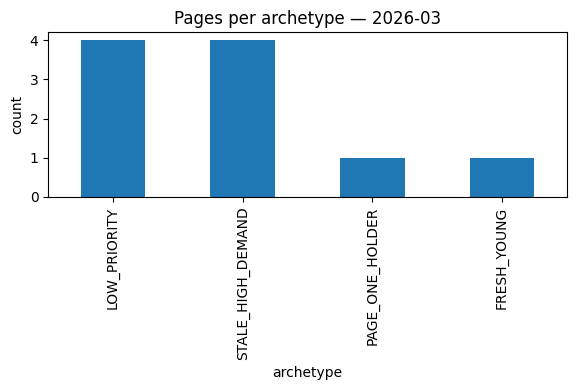

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Queue CSV — regenerated each run, stays out of git per the leak-guard
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

# Metrics JSON — the receipts, this one gets committed
import json
metrics = {
    "month": "2026-03",
    "n_pages_scored": len(queue),
    "n_flagged_refresh": int((queue["action_label"] == "REFRESH").sum()),
    "n_flagged_improve_snippet": int((queue["action_label"] == "IMPROVE_SNIPPET").sum()),
    "top_20_avg_action_score": float(queue.head(20)["action_score"].mean()),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

# Figure to reuse in the paper
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
queue["archetype"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Pages per archetype — 2026-03")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig("work/figures/archetype_distribution.png", dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.